<a href="https://colab.research.google.com/github/gita-mankar/VOIS_AICTE_OCT2025_GitanjaliMankar/blob/main/AIRBNB_hotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
df = pd.read_csv('/content/Copy of 1730285881-Airbnb_Open_Data.csv', low_memory=False, encoding='latin1')

In [8]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93831 entries, 0 to 93830
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              93831 non-null  int64  
 1   NAME                            93597 non-null  object 
 2   host id                         93831 non-null  int64  
 3   host_identity_verified          93558 non-null  object 
 4   host name                       93442 non-null  object 
 5   neighbourhood group             93802 non-null  object 
 6   neighbourhood                   93815 non-null  object 
 7   lat                             93823 non-null  float64
 8   long                            93823 non-null  float64
 9   country                         93467 non-null  object 
 10  country code                    93731 non-null  object 
 11  instant_bookable                93731 non-null  object 
 12  cancellation_policy             

In [10]:
df.duplicated().value_counts()

,count
False,93831


In [11]:
df.drop_duplicates(inplace=True)
display(df.duplicated().value_counts())

,count
False,93831


In [12]:
df[df['neighbourhood group'] == 'brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,24-06-2019,1.34,4.0,3.0,47.0,NaN,NaN


In [13]:
df.columns = df.columns.str.strip()
print(df.columns)

df.drop_duplicates(inplace=True)

# Define a function to clean currency strings
def clean_currency(s):
    if isinstance(s, str):
        return s.replace('$', '').replace(',', '')
    return s

# Check actual column names before applying
print("Available columns:", df.columns)

# Fix column names if they differ in case
if 'Price' in df.columns:
    df.rename(columns={'Price': 'price'}, inplace=True)
if 'Service fee' in df.columns:
    df.rename(columns={'Service fee': 'service fee'}, inplace=True)

# Apply cleaning only if columns exist
if 'price' in df.columns:
    df['price'] = df['price'].apply(clean_currency)
if 'service fee' in df.columns:
    df['service fee'] = df['service fee'].apply(clean_currency)

df.rename(columns={
    'price': 'price_$',
    'service fee': 'service_fee_$'
}, inplace=True)

if 'price_$' in df.columns:
    df['price_$'] = df['price_$'].astype(float)
if 'service_fee_$' in df.columns:
    df['service_fee_$'] = df['service_fee_$'].astype(float)

if 'id' in df.columns:
    df['id'] = df['id'].astype(str)
if 'host id' in df.columns:
    df['host id'] = df['host id'].astype(str)
if 'last review' in df.columns:
    df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Fill NaN values in 'Construction year' with 0 before converting to int
if 'Construction year' in df.columns:
    df['Construction year'] = df['Construction year'].fillna(0).astype(int)

if 'neighbourhood group' in df.columns:
    df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

if 'availability 365' in df.columns:
    df.drop(df[df['availability 365'] > 500].index, inplace=True)


Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')
Available columns: Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype

/tmp/ipython-input-4095341389.py:42: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'], errors='coerce')


In [14]:
df.duplicated().value_counts()

,count
False,93830


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93830 entries, 0 to 93830
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              93830 non-null  object        
 1   NAME                            93596 non-null  object        
 2   host id                         93830 non-null  object        
 3   host_identity_verified          93557 non-null  object        
 4   host name                       93441 non-null  object        
 5   neighbourhood group             93801 non-null  object        
 6   neighbourhood                   93814 non-null  object        
 7   lat                             93822 non-null  float64       
 8   long                            93822 non-null  float64       
 9   country                         93466 non-null  object        
 10  country code                    93730 non-null  object        
 11  instant

In [16]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,93822.000000,93822.000000,93830.000000,93612.000000,93589.000000,93449.000000,93650.000000,79098,79111.000000,93527.000000,93545.000000,93382.000000
mean,40.728226,-73.949797,2008.151487,624.898165,124.944823,8.259136,28.152226,2019-06-22 06:35:49.131457280,1.359267,3.271996,8.184927,143.801193
min,40.499790,-74.249840,0.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.688750,-73.982660,2007.000000,339.000000,68.000000,2.000000,1.000000,2018-10-21 00:00:00,0.210000,2.000000,1.000000,5.000000
50%,40.722445,-73.954605,2012.000000,624.000000,125.000000,3.000000,7.000000,2019-06-15 00:00:00,0.730000,3.000000,1.000000,104.000000
75%,40.762840,-73.932600,2017.000000,912.000000,182.000000,5.000000,31.000000,2019-07-07 00:00:00,2.000000,4.000000,2.000000,272.000000
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.055761,0.049376,93.454029,331.767987,66.346869,31.483890,50.827581,NaN,1.750922,1.288860,33.287463,135.211987


In [17]:
property_type = df['room type'].value_counts().to_frame()
property_type

,count
room type,
Entire home/apt,49505
Private room,42227
Shared room,1983
Hotel room,115


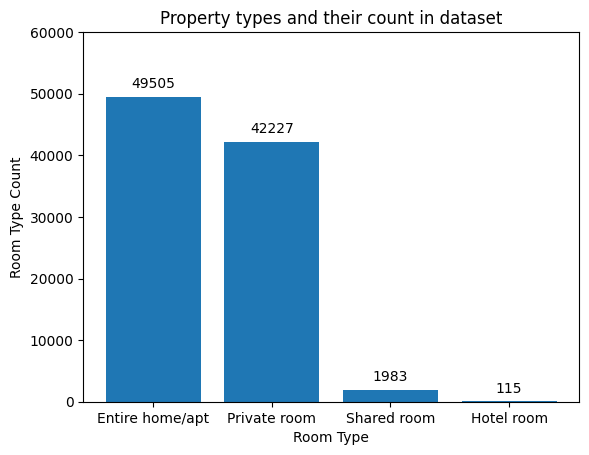

In [18]:
room_type_bar = plt.bar(property_type.index, property_type.loc[:,"count"]);
plt.bar_label(room_type_bar, labels= property_type.loc[:,"count"],padding = 4);
plt.ylim([0,60000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Property types and their count in dataset');

In [19]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Manhattan,40220
Brooklyn,38188
Queens,12074
Bronx,2462
Staten Island,856
manhatan,1


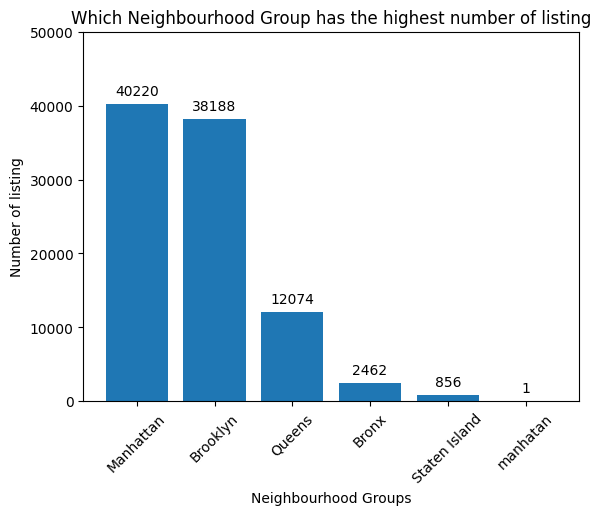

In [20]:
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar, labels= hood_group.loc[:,"count"],padding = 4);
plt.ylim([0,50000]);
plt.xlabel('Neighbourhood Groups');
plt.ylabel('Number of listing');
plt.xticks(rotation=45);
plt.title('Which Neighbourhood Group has the highest number of listing');

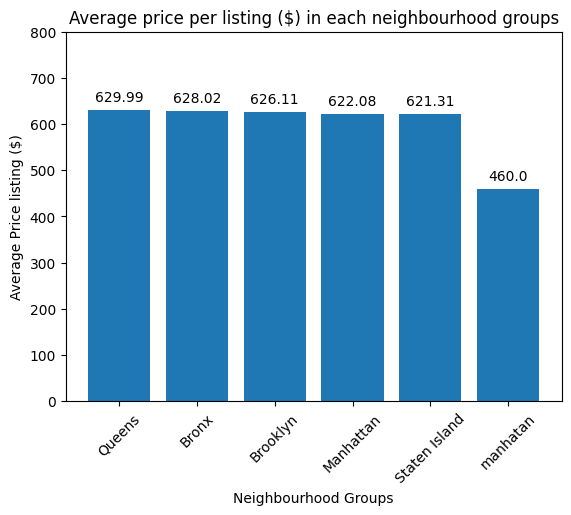

In [25]:
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending=False).to_frame()
avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:, "price_$"])
plt.bar_label(avg_price_bar, labels=round(avg_price.loc[:, "price_$"], 2), label_type='edge', padding=4)
plt.ylim([0, 800])
plt.xlabel('Neighbourhood Groups')
plt.ylabel('Average Price listing ($)')
plt.xticks(rotation=45)
plt.title('Average price per listing ($) in each neighbourhood groups')
plt.show()


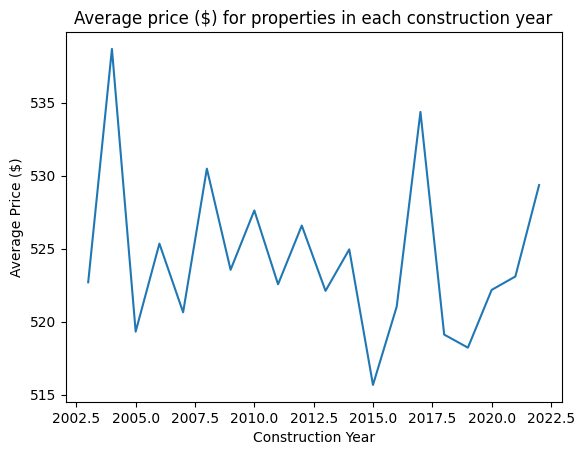

In [28]:
df_clean = df[(df['Construction year'] > 1800) & (df['price_$'] > 0) & (df['price_$'] < 1000)]
df_clean.groupby('Construction year')['price_$'].mean().sort_index().plot()
plt.xlabel('Construction Year')
plt.ylabel('Average Price ($)')
plt.title('Average price ($) for properties in each construction year')
plt.show()


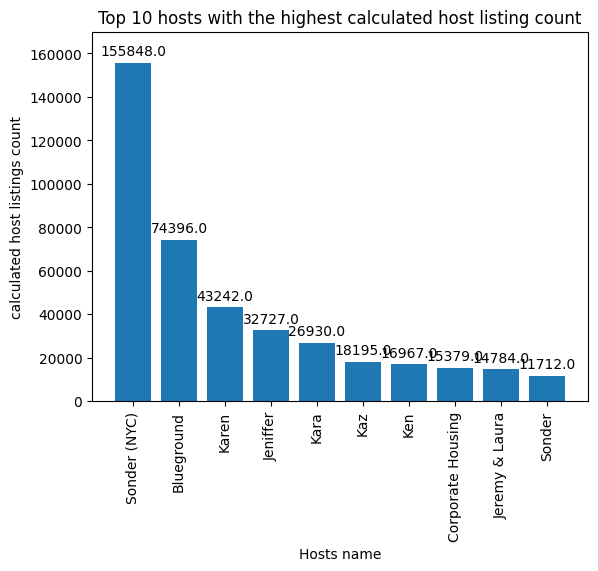

In [35]:
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(10).to_frame()
host_bar_plot = plt.bar(hosts.index, hosts.loc[:,"calculated host listings count"]);
plt.bar_label(host_bar_plot, labels=hosts.loc[:,"calculated host listings count"],label_type= 'edge',padding = 3);
plt.xlabel('Hosts name');
plt.ylabel('calculated host listings count');
plt.xticks(rotation=90);
plt.ylim([0,170000]);
plt.title('Top 10 hosts with the highest calculated host listing count');

In [37]:
review = df.groupby('host_identity_verified')['review rate number'].sum().sort_values(ascending=False).to_frame()
review

,review rate number
host_identity_verified,
verified,153023.0
unconfirmed,152162.0


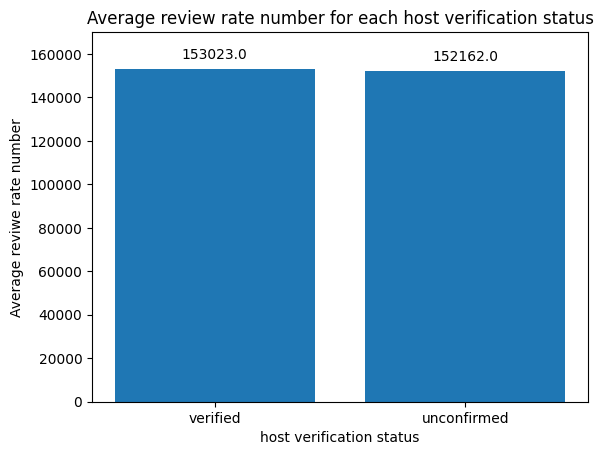

In [47]:
review_bar = plt.bar(review.index, review.loc[:,"review rate number"]);
plt.bar_label(review_bar, labels=round(review.loc[:,"review rate number"], 2 ),padding = 5);
plt.ylim([0,170000]);
plt.xlabel('host verification status');
plt.ylabel('Average reviwe rate number');
plt.title('Average review rate number for each host verification status');

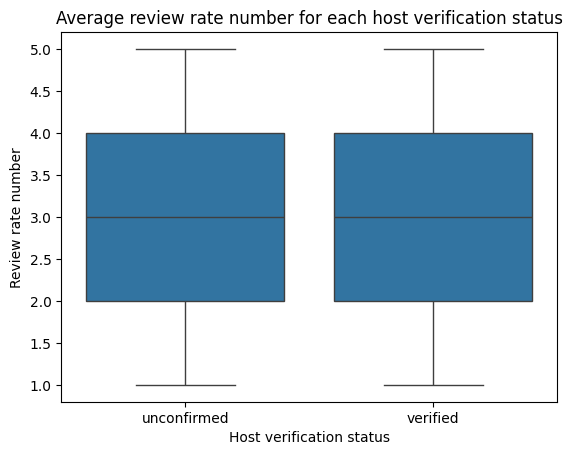

In [51]:
base_color = sns.color_palette()[0]
sns.boxplot(data=df, x="host_identity_verified", y="review rate number", color=base_color)
plt.xlabel('Host verification status')
plt.ylabel('Review rate number')
plt.title('Average review rate number for each host verification status')
plt.show()

In [52]:
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999908922152269)

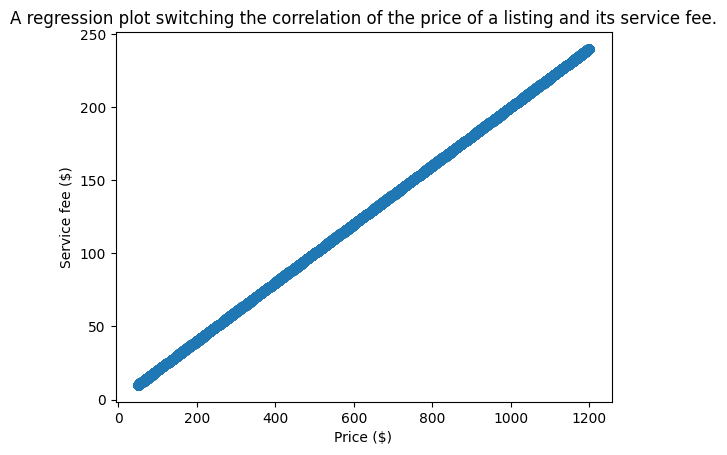

In [53]:
sns.regplot(df, x='price_$', y='service_fee_$');
plt.xlabel('Price ($)');
plt.ylabel('Service fee ($)');
plt.title('A regression plot switching the correlation of the price of a listing and its service fee.');

In [56]:
ARRN = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.358672
                    Private room               3.331201
                    Shared room                3.228571
Brooklyn            Entire home/apt            3.239881
                    Hotel room                 3.857143
                    Private room               3.255747
                    Shared room                3.334250
Manhattan           Entire home/apt            3.269076
                    Hotel room                 3.500000
                    Private room               3.271084
                    Shared room                3.244772
Queens              Entire home/apt            3.353664
                    Hotel room                 3.750000
                    Private room               3.310345
                    Shared room                3.325000
Staten Island       Entire home/apt            3.312073
                    Private room               3.495000
                    Shared room                3.454545
manhatan            Private room               3.000000

Text(0.5, 1.0, 'Average Review Rate for each room/property type in each Neighbourhood Group')

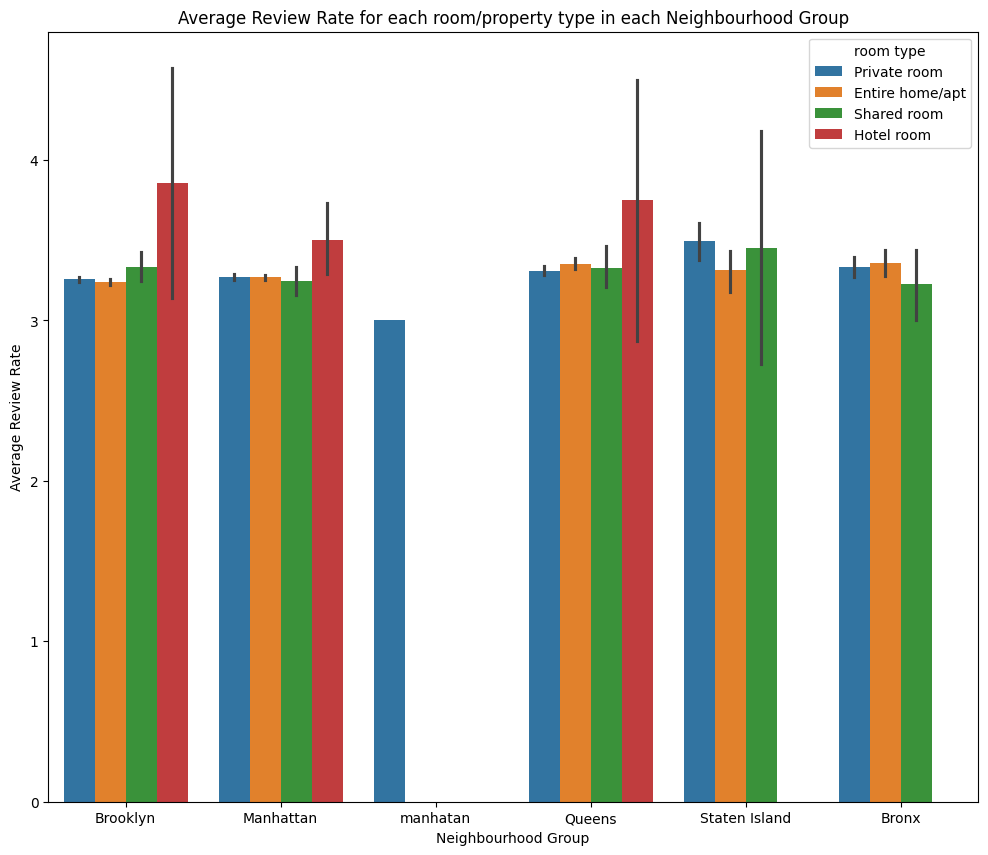

In [58]:
plt.figure(figsize=(12, 10))
sns.barplot(data = df, x='neighbourhood group', y='review rate number', hue='room type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Review Rate')
plt.title('Average Review Rate for each room/property type in each Neighbourhood Group')

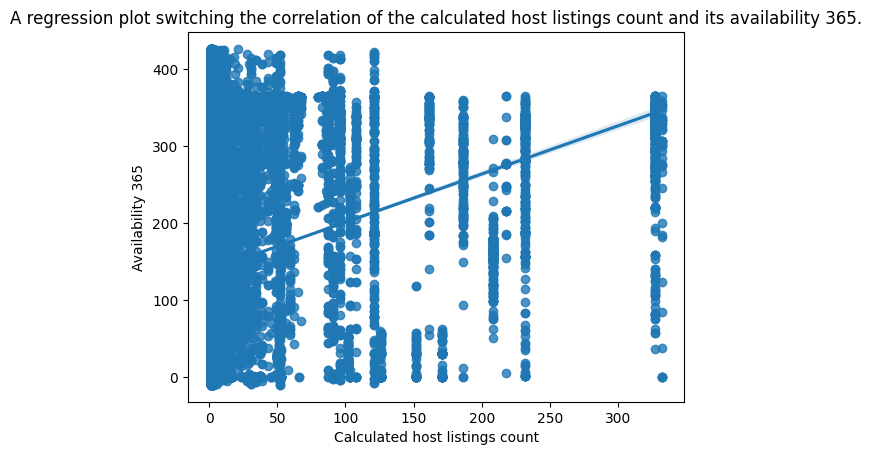

In [59]:
sns.regplot(df, x = 'calculated host listings count', y ='availability 365');
plt.xlabel('Calculated host listings count');
plt.ylabel('Availability 365')
plt.title('A regression plot switching the correlation of the calculated host listings count and its availability 365.');

In [60]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.15421894780789172)